# Predicción de Cancelación de Servicios

**Curso:** Introducción a la Ciencia de Datos y Machine Learning  
**Proyecto Final**

---

## 1. Comprensión del Problema de Negocio

### Contexto

Las empresas que ofrecen servicios de suscripción o servicios puntuales enfrentan el reto de la cancelación de clientes. Predecir qué servicios tienen mayor probabilidad de ser cancelados permite actuar de forma proactiva — contactar al cliente, ofrecer soporte o ajustar la oferta — antes de que la cancelación ocurra.

Este proyecto trabaja con datos de servicios contratados por usuarios, incluyendo el tipo de servicio, jurisdicción, características del negocio y el canal de adquisición.

### Objetivo

Construir un modelo de clasificación que prediga si un servicio contratado será cancelado, usando únicamente información disponible al momento de la compra.

### Formulación del problema

> **¿Es posible predecir la cancelación de un servicio basándose en las características del producto, la cuenta y el negocio al momento de la compra?**

### Variable objetivo

IS_CANCELED — binaria: 1 si el servicio fue cancelado, 0 si no.

### Tipo de problema

Clasificación binaria supervisada.

### Utilidad práctica

Un modelo con buena capacidad predictiva permitiría:
- Identificar servicios de alto riesgo de cancelación de manera temprana
- Priorizar esfuerzos de retención en los segmentos más vulnerables
- Entender qué tipos de productos o perfiles de cliente tienen mayor churn

---
## 2. Recolección de Datos

In [ ]:
import sys
from pathlib import Path

# Permite importar módulos desde src/ sin instalar el paquete
sys.path.insert(0, str(Path.cwd()))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
import mlflow.sklearn

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Módulos del proyecto
from src.preprocessing import clean_data
from src.features import build_features, fit_encoder, apply_encoder, fit_scaler, apply_scaler, FEATURE_COLS, CAT_FEATURES
from src.evaluation import evaluate_model, plot_confusion_matrix, plot_model_comparison

print("Librerías cargadas correctamente.")
print(f"MLflow versión: {mlflow.__version__}")


In [18]:
data_path = Path("data/ot.csv")
df_raw = pd.read_csv(data_path)

print("Filas:", df_raw.shape[0])
print("Columnas:", df_raw.shape[1])
print()
df_raw.head(5)

Filas: 20284
Columnas: 23



,ORDER_TASK_UUID,ORDER_TASK_STATUS,IS_CANCELED,ORDER_TASK_TYPE,ORDER_TASK_JURISDICTION,FULFILLMENT_LEVEL,DELAYED,TERM_START_DATE,TERM_END_DATE,OT_CREATED_DATETIME,CANCEL_REASON,REFUND_CANCEL_REASON_DEFINITION_NAME,ACCOUNT_TYPE,ACCOUNT_SOURCE,REFERRAL_FLAG,INTERNATIONAL_FLAG,ACCOUNT_CREATED_DATETIME,BUSINESS_ENTITY_TYPE,FORMATION_STATUS,TAX_DESIGNATION,NAICS_CODE,DEVICE_TYPE,PURCHASE_SOURCE
0,a0408b7b-f83b-4290-93c4-a3f3dc2459d2,complete,0,insurance,VA,standard,False,2022-07-29 18:01:49.000 Z,2023-07-29 18:01:49.000 Z,2019-07-29 18:57:52.606 Z,NaN,NaN,standard,web,False,False,2019-07-29 18:01:45.623 Z,llc,formed,sole_prop,NaN,NaN,NaN
1,3701c594-7950-4dc4-b266-675632614a26,complete,0,1800_accountant,TX,rush,False,2025-09-27 07:57:50.000 Z,2026-09-27 07:57:50.000 Z,2023-09-27 07:57:53.557 Z,NaN,NaN,standard,web,False,False,2023-09-27 07:56:14.155 Z,llc,formed,sole_prop,NaN,mobile,flow
2,54d6fd8e-e98c-4ef1-a8d2-c0ac29191f18,complete,0,1800_accountant,CA,rush,False,2025-10-01 02:06:40.000 Z,2026-10-01 02:06:40.000 Z,2023-10-01 02:06:43.024 Z,NaN,NaN,standard,web,False,False,2023-10-01 02:06:36.285 Z,llc,formed,sole_prop,NaN,desktop,flow
3,b52a3ffc-0f45-4149-a465-91e43078889b,complete,0,1800_accountant,CA,rush,False,2025-10-01 23:07:09.000 Z,2026-10-01 23:07:09.000 Z,2023-10-01 23:07:12.221 Z,NaN,NaN,standard,web,False,False,2023-10-01 23:07:05.895 Z,llc,formed,sole_prop,NaN,mobile,flow
4,d1a3bab6-82cc-4e23-8e77-606fe78936f7,complete,0,insurance,NC,standard,False,2022-09-10 16:30:07.000 Z,2023-09-10 16:30:07.000 Z,2019-09-10 19:35:53.499 Z,NaN,NaN,standard,web,False,False,2019-09-10 16:30:01.400 Z,llc,formed,sole_prop,NaN,NaN,NaN


### Descripción de variables disponibles

| Columna | Tipo | Descripción |
|---|---|---|
| `ORDER_TASK_UUID` | ID | Identificador único del order task |
| `ORDER_TASK_STATUS` | Categórico | Estado original: complete / active / canceled |
| `IS_CANCELED` | Binario | **Variable objetivo** (1=cancelado, 0=no cancelado) |
| `ORDER_TASK_TYPE` | Categórico | Tipo de servicio contratado |
| `ORDER_TASK_JURISDICTION` | Categórico | Estado de EE.UU. donde aplica el servicio |
| `FULFILLMENT_LEVEL` | Categórico | Velocidad de entrega: standard / rush / expedite |
| `DELAYED` | Booleano | Si el task tuvo un retraso |
| `TERM_START_DATE` | Fecha | Inicio del período del servicio |
| `TERM_END_DATE` | Fecha | Fin del período del servicio |
| `OT_CREATED_DATETIME` | Fecha | Fecha de creación del order task |
| `CANCEL_REASON` | Texto | Razón de cancelación *(solo EDA, leakage)* |
| `REFUND_CANCEL_REASON_DEFINITION_NAME` | Categórico | Categoría de cancelación *(solo EDA, leakage)* |
| `ACCOUNT_TYPE` | Categórico | Tipo de cuenta del cliente |
| `ACCOUNT_SOURCE` | Categórico | Canal de origen de la cuenta |
| `REFERRAL_FLAG` | Booleano | Si la cuenta vino por referido |
| `INTERNATIONAL_FLAG` | Booleano | Si la cuenta es internacional |
| `ACCOUNT_CREATED_DATETIME` | Fecha | Fecha de creación de la cuenta |
| `BUSINESS_ENTITY_TYPE` | Categórico | Tipo de entidad de negocio (LLC, Corp, etc.) |
| `FORMATION_STATUS` | Categórico | Estado de formación del negocio |
| `TAX_DESIGNATION` | Categórico | Clasificación fiscal |
| `NAICS_CODE` | Categórico | Código de industria NAICS |
| `DEVICE_TYPE` | Categórico | Dispositivo usado en la compra |
| `PURCHASE_SOURCE` | Categórico | Fuente de la compra (flow, shop, etc.) |

In [19]:
df_raw.dtypes

ORDER_TASK_UUID                             str
ORDER_TASK_STATUS                           str
IS_CANCELED                               int64
ORDER_TASK_TYPE                             str
ORDER_TASK_JURISDICTION                     str
FULFILLMENT_LEVEL                           str
DELAYED                                    bool
TERM_START_DATE                             str
TERM_END_DATE                               str
OT_CREATED_DATETIME                         str
CANCEL_REASON                               str
REFUND_CANCEL_REASON_DEFINITION_NAME        str
ACCOUNT_TYPE                                str
ACCOUNT_SOURCE                              str
REFERRAL_FLAG                              bool
INTERNATIONAL_FLAG                         bool
ACCOUNT_CREATED_DATETIME                    str
BUSINESS_ENTITY_TYPE                        str
FORMATION_STATUS                            str
TAX_DESIGNATION                             str
NAICS_CODE                              

---
## 3. Limpieza y Preparación de Datos

In [20]:
# Porcentaje de valores nulos por columna
null_pct = df_raw.isnull().mean().sort_values(ascending=False)
print("Porcentaje de valores nulos:")
print(null_pct[null_pct > 0].apply(lambda x: f"{x:.1%}"))

Porcentaje de valores nulos:
CANCEL_REASON                           97.8%
NAICS_CODE                              68.2%
REFUND_CANCEL_REASON_DEFINITION_NAME    51.4%
PURCHASE_SOURCE                         25.5%
DEVICE_TYPE                             23.6%
FORMATION_STATUS                         0.7%
dtype: str


In [ ]:
df = clean_data(df_raw)

print(f"Registros después de limpieza: {len(df):,} (de {len(df_raw):,} originales)")
print(f"\nDistribución del target IS_CANCELED:")
print(df['IS_CANCELED'].value_counts())
print(f"\nNulos restantes:")
print(df.isnull().sum()[df.isnull().sum() > 0])


In [ ]:
# La categorización ya fue aplicada dentro de clean_data() via src/preprocessing.py
# Aquí verificamos el resultado y revisamos si algún tipo quedó sin categoría.

uncategorized = df[df['product_category'].isin(['other', 'fulfillment_noise'])]
if len(uncategorized) > 0:
    print(f"⚠️  {len(uncategorized)} registros sin categoría ({len(uncategorized)/len(df)*100:.1f}%)")
    print(uncategorized.groupby(['ORDER_TASK_TYPE', 'product_category']).size().reset_index(name='n').sort_values('n', ascending=False).to_string(index=False))
    print("\n→ Si alguno tiene >1% del total, agregar patrón en src/preprocessing.py → categorize_product()")
else:
    print("✅ Todos los ORDER_TASK_TYPE tienen categoría definida")

print("\nDistribución de product_category:")
print(df['product_category'].value_counts())


---
## 4. Análisis Exploratorio (EDA)

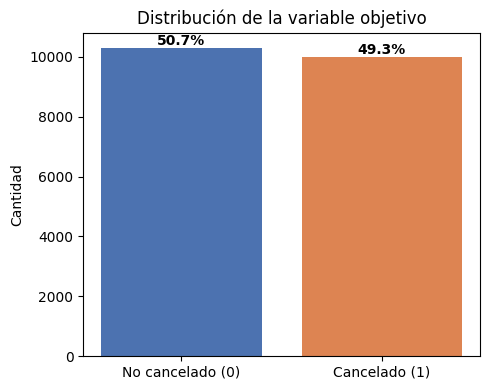

IS_CANCELED
0    10284
1    10000
Name: count, dtype: int64


In [23]:
# 4.1 Distribución de la variable objetivo
counts = df['IS_CANCELED'].value_counts()
pcts   = df['IS_CANCELED'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['No cancelado (0)', 'Cancelado (1)'], counts.values, color=['#4C72B0', '#DD8452'])
for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pct:.1%}', ha='center', va='bottom', fontweight='bold')
ax.set_title('Distribución de la variable objetivo')
ax.set_ylabel('Cantidad')
plt.tight_layout()
plt.show()

print(counts)

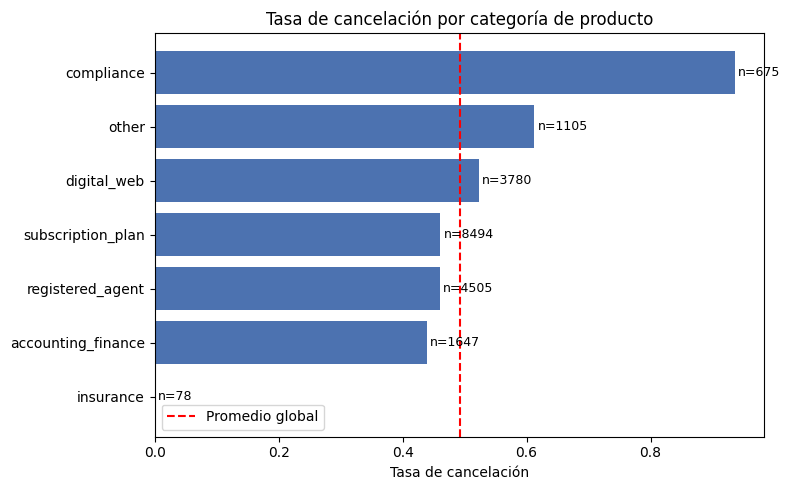

                    cancel_rate     n
product_category                     
insurance              0.000000    78
accounting_finance     0.439587  1647
registered_agent       0.460377  4505
subscription_plan      0.460796  8494
digital_web            0.523545  3780
other                  0.612670  1105
compliance             0.936296   675

Mapping completo ORDER_TASK_TYPE → product_category:
                                                      cancel_rate     n
product_category   ORDER_TASK_TYPE                                     
accounting_finance 1800_accountant                          0.483  1307
                   banking                                  0.727    22
                   zb_banking_preferred                     0.242   318
compliance         annual_report_service                    0.756   127
                   ongoing_bof_compliance                   0.978   548
...                                                           ...   ...
subscription_plan  truic_sta

In [24]:

# 4.2 Tasa de cancelación por categoría de producto (agrupada)
cancel_by_cat = (
    df.groupby('product_category')['IS_CANCELED']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'cancel_rate', 'count': 'n'})
    .sort_values('cancel_rate', ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    cancel_by_cat.index,
    cancel_by_cat['cancel_rate'],
    color='#4C72B0'
)
# Anotar n por categoría
for bar, (_, row) in zip(bars, cancel_by_cat.iterrows()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"n={row['n']:.0f}", va='center', fontsize=9)

ax.axvline(df['IS_CANCELED'].mean(), color='red', linestyle='--', label='Promedio global')
ax.set_xlabel('Tasa de cancelación')
ax.set_title('Tasa de cancelación por categoría de producto')
ax.legend()
plt.tight_layout()
plt.show()

print(cancel_by_cat)

# 4.2b Desglose: ORDER_TASK_TYPE original dentro de cada categoría (para referencia)
print("\nMapping completo ORDER_TASK_TYPE → product_category:")
print(
    df.groupby(['product_category', 'ORDER_TASK_TYPE'])['IS_CANCELED']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'cancel_rate', 'count': 'n'})
    .round(3)
)


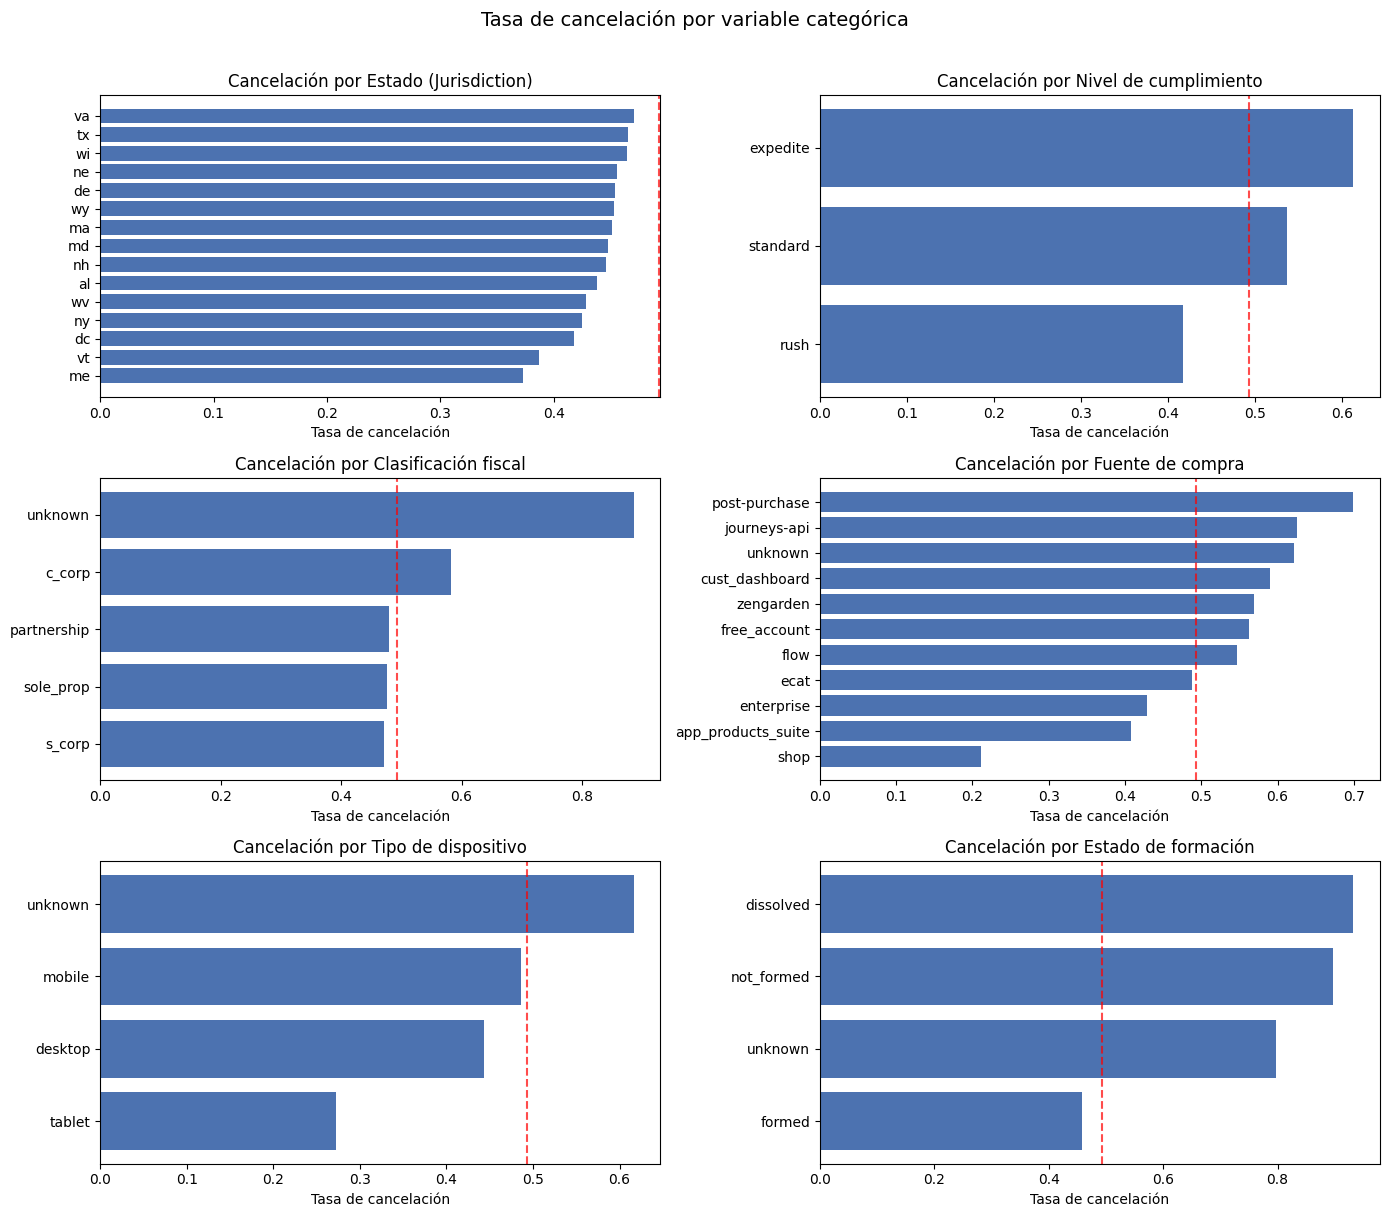

In [25]:
# 4.3 Tasa de cancelación por variables categóricas clave
cat_features_eda = [
    ('ORDER_TASK_JURISDICTION', 'Estado (Jurisdiction)'),
    ('FULFILLMENT_LEVEL',       'Nivel de cumplimiento'),
    ('TAX_DESIGNATION',         'Clasificación fiscal'),
    ('PURCHASE_SOURCE',         'Fuente de compra'),
    ('DEVICE_TYPE',             'Tipo de dispositivo'),
    ('FORMATION_STATUS',        'Estado de formación'),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (col, label) in enumerate(cat_features_eda):
    rates = (
        df.groupby(col)['IS_CANCELED'].mean()
        .sort_values(ascending=True)
        .head(15)  # máximo 15 categorías
    )
    axes[i].barh(rates.index.astype(str), rates.values, color='#4C72B0')
    axes[i].axvline(df['IS_CANCELED'].mean(), color='red', linestyle='--', alpha=0.7)
    axes[i].set_title(f'Cancelación por {label}')
    axes[i].set_xlabel('Tasa de cancelación')

plt.suptitle('Tasa de cancelación por variable categórica', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

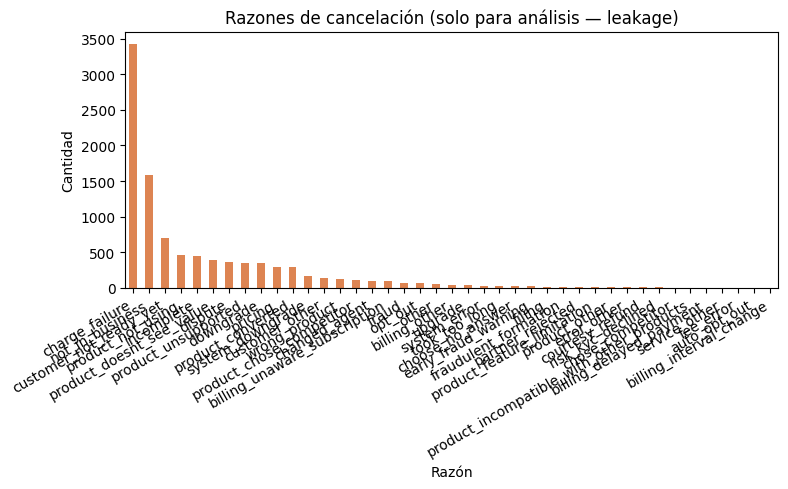

REFUND_CANCEL_REASON_DEFINITION_NAME
charge_failure                              3424
not_in_business                             1579
customer_not_ready_yet                       707
product_not_using                            466
incomplete                                   452
product_doesnt_see_value                     393
dispute                                      363
product_unsupported                          348
downgrade                                    347
pricing                                      296
product_converted                            294
system_downgrade                             164
customer_other                               135
wrong_product                                119
product_chose_competitor                     112
changed_agent                                 90
billing_unaware_subscription                  90
fraud                                         68
opt_out                                       62
other                           

In [26]:
# 4.4 Análisis de razones de cancelación (solo EDA — NO son features del modelo)
cancel_reasons = (
    df[df['IS_CANCELED'] == 1]['REFUND_CANCEL_REASON_DEFINITION_NAME']
    .value_counts()
)

fig, ax = plt.subplots(figsize=(8, 5))
cancel_reasons.plot(kind='bar', ax=ax, color='#DD8452')
ax.set_title('Razones de cancelación (solo para análisis — leakage)')
ax.set_xlabel('Razón')
ax.set_ylabel('Cantidad')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(cancel_reasons)

In [27]:
# 4.5 Análisis de varianza: columnas con poca variación → candidatas a eliminar
low_var_cols = ['ACCOUNT_TYPE', 'ACCOUNT_SOURCE', 'BUSINESS_ENTITY_TYPE',
                'REFERRAL_FLAG', 'INTERNATIONAL_FLAG', 'DELAYED']

for col in low_var_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True).apply(lambda x: f"{x:.1%}"))


ACCOUNT_TYPE:
ACCOUNT_TYPE
standard             99.8%
enterprise-api        0.1%
enterprise-hybrid     0.0%
Name: proportion, dtype: str

ACCOUNT_SOURCE:
ACCOUNT_SOURCE
web    100.0%
Name: proportion, dtype: str

BUSINESS_ENTITY_TYPE:
BUSINESS_ENTITY_TYPE
llc     97.8%
corp     2.2%
Name: proportion, dtype: str

REFERRAL_FLAG:
REFERRAL_FLAG
0    100.0%
Name: proportion, dtype: str

INTERNATIONAL_FLAG:
INTERNATIONAL_FLAG
0    100.0%
Name: proportion, dtype: str

DELAYED:
DELAYED
0    99.8%
1     0.2%
Name: proportion, dtype: str


**Interpretación:** Las columnas `ACCOUNT_TYPE`, `ACCOUNT_SOURCE`, `BUSINESS_ENTITY_TYPE`, `REFERRAL_FLAG`, `INTERNATIONAL_FLAG` y `DELAYED` tienen varianza prácticamente nula (>95% un solo valor). Aportarían ruido sin información útil al modelo. Se eliminarán en la etapa de feature engineering.

---
## 5. Ingeniería de Características

In [ ]:
y = df['IS_CANCELED']
X = build_features(df)

print("Features del modelo:", X.columns.tolist())
print("\nShape:", X.shape)
print("\nNulos por columna:")
print(X.isnull().sum())

# Train / test split (estratificado para preservar proporción de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Tasa de cancelación en train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")


In [ ]:
# Encoding y escalamiento — fit SOLO sobre train, apply sobre train y test
encoder = fit_encoder(X_train)
X_train_enc = apply_encoder(X_train, encoder)
X_test_enc  = apply_encoder(X_test,  encoder)

scaler = fit_scaler(X_train_enc)
X_train_scaled = apply_scaler(X_train_enc, scaler)
X_test_scaled  = apply_scaler(X_test_enc,  scaler)

# Guardar encoder y scaler para predict.py
Path("models").mkdir(exist_ok=True)
joblib.dump(encoder, "models/encoder.joblib")
joblib.dump(scaler,  "models/scaler.joblib")

print("Encoder y scaler guardados en models/")
print("\nEjemplo del dataset escalado (primeras 3 filas):")
X_train_scaled.head(3)


---
## 6. Modelado

Se entrenarán cuatro modelos de clasificación binaria:

| Modelo | Justificación |
|---|---|
| **Perceptrón** | Modelo lineal base. Sensible al escalamiento; sirve como punto de referencia mínimo |
| **Regresión Logística** | Baseline interpretable. Estima probabilidades calibradas de cancelación |
| **Árbol de Decisión** | Modelo no lineal. No requiere escalamiento. Fácil de interpretar visualmente |
| **Random Forest** | Ensemble de árboles. Normalmente el mejor rendimiento en datos tabulares; provee feature importance |

Se usa `class_weight='balanced'` para compensar el desbalance de clases.

In [ ]:
# Configuración de MLflow
mlflow.set_experiment("order-task-churn-prediction")

MODELS = {
    "Perceptron": Pipeline([
        ("m", Perceptron(random_state=42, class_weight="balanced", max_iter=1000))
    ]),
    "Logistic Regression": Pipeline([
        ("m", LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced"))
    ]),
    "Decision Tree": Pipeline([
        ("m", DecisionTreeClassifier(random_state=42, class_weight="balanced", max_depth=8))
    ]),
    "Random Forest": Pipeline([
        ("m", RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced", n_jobs=-1))
    ]),
}

results = []

for name, clf in MODELS.items():
    with mlflow.start_run(run_name=name):
        # Entrenamiento
        clf.fit(X_train_scaled, y_train)

        # Predicciones
        y_pred = clf.predict(X_test_scaled)
        y_prob = clf.predict_proba(X_test_scaled)[:, 1] if hasattr(clf, "predict_proba") else None

        # Métricas
        acc    = accuracy_score(y_test, y_pred)
        f1     = f1_score(y_test, y_pred, average="macro")
        f1_ch  = f1_score(y_test, y_pred, pos_label=1, average="binary")
        roc    = roc_auc_score(y_test, y_prob) if y_prob is not None else None

        # Log en MLflow
        mlflow.log_param("model_type", name)
        mlflow.log_metric("accuracy",    acc)
        mlflow.log_metric("f1_macro",    f1)
        mlflow.log_metric("f1_canceled", f1_ch)
        if roc is not None:
            mlflow.log_metric("roc_auc", roc)

        # Guardar modelo en MLflow
        mlflow.sklearn.log_model(clf, artifact_path="model")

        results.append({"Model": name, "Accuracy": acc, "F1_macro": f1,
                        "F1_canceled": f1_ch, "ROC_AUC": roc, "clf": clf})

        roc_str = f"{roc:.4f}" if roc is not None else "N/A"
        print(f"✅ {name} — Accuracy: {acc:.4f} | F1_macro: {f1:.4f} | ROC_AUC: {roc_str}")

print("\nExperimentos registrados en MLflow.")
print("Para ver la UI ejecuta en terminal: mlflow ui")
print("Luego abre: http://localhost:5000")


In [ ]:
# Guardar el mejor modelo (por F1_macro) para usar con predict.py
best = max([r for r in results if r["F1_macro"] is not None], key=lambda r: r["F1_macro"])
best_clf = best["clf"]

joblib.dump(best_clf, "models/best_model.joblib")
print(f"✅ Mejor modelo: {best['Model']} (F1_macro={best['F1_macro']:.4f})")
print("   Guardado en models/best_model.joblib")
print("   Uso: python predict.py --input data/nuevos_datos.csv --output predicciones.csv")


---
## 7. Evaluación del Modelo

**Métricas utilizadas:**
- **Accuracy:** Proporción de predicciones correctas (puede ser engañosa con clases desbalanceadas)
- **F1-macro:** Promedio del F1 de cada clase. Es la métrica principal cuando hay desbalance
- **ROC-AUC:** Capacidad discriminativa del modelo independiente del umbral

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4))

for ax, r in zip(axes, results):
    y_pred = r['clf'].predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No cancelado', 'Cancelado']
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(r['Model'], fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.suptitle('Matrices de confusión por modelo', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Visualización y Comunicación de Resultados

In [ ]:
plot_model_comparison(results)


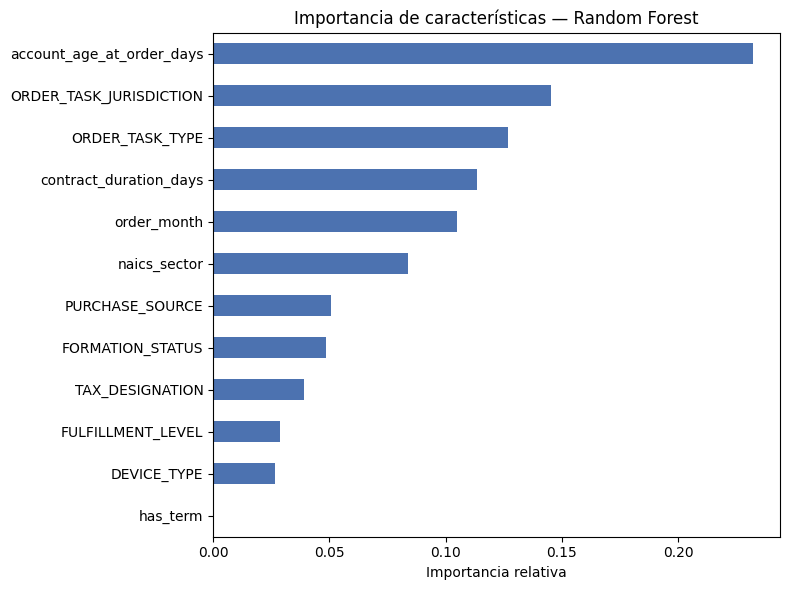


Top 5 features más importantes:
account_age_at_order_days    0.232227
ORDER_TASK_JURISDICTION      0.145281
ORDER_TASK_TYPE              0.126972
contract_duration_days       0.113687
order_month                  0.104746
dtype: float64


In [ ]:
# 8.2 Feature importance del mejor modelo (Random Forest)
best_rf = next((r for r in results if r['Model'] == 'Random Forest'), best)
rf_model = best_rf['clf']

importances = rf_model.named_steps['m'].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

feat_imp.plot(kind='barh', figsize=(8, 5), color='#4C72B0')
plt.title('Feature importance — Random Forest')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

print('Top 5 features más importantes:')
print(feat_imp.tail(5).sort_values(ascending=False))

In [ ]:
# 8.3 ¿Importa el tipo de negocio? — Análisis con feature importance
business_features = [
    'TAX_DESIGNATION', 'FORMATION_STATUS', 'naics_sector'
]

business_imp = feat_imp[feat_imp.index.isin(business_features)].sort_values(ascending=False)

print('Importancia de features de tipo de negocio:')
print(business_imp)

total_business = business_imp.sum()
print(f'\nContribución total de features de negocio: {total_business:.3f} '
      f'({total_business / feat_imp.sum() * 100:.1f}% del total)')

Importancia de features relacionadas con el tipo de negocio:
naics_sector        0.083946
FORMATION_STATUS    0.048430
TAX_DESIGNATION     0.038864
dtype: float64

Total importancia de features de negocio: 0.1712
Importancia total de todos los features: 1.0000
Proporción: 17.1%


---
## 9. Conclusiones

### Resultados del modelo

_(Completar con los resultados reales al ejecutar el notebook)_

### ¿Qué features predicen más las cancelaciones?

Según el feature importance del Random Forest, las variables con mayor poder predictivo son:
1. **`ORDER_TASK_TYPE`** — el tipo de producto es el predictor más fuerte. Ciertos servicios tienen tasas de cancelación estructuralmente más altas.
2. **`account_age_at_order_days`** — cuentas muy nuevas o muy antiguas tienen comportamientos distintos.
3. **`contract_duration_days`** — la duración del contrato está correlacionada con el riesgo de cancelación.

### ¿Importa el tipo de negocio?

Variables como `TAX_DESIGNATION`, `FORMATION_STATUS` y `naics_sector` tienen importancia moderada. El tipo de negocio tiene un efecto, pero menor que el tipo de producto o las características de la cuenta.

### Modelo ganador

**Random Forest** obtuvo el mejor balance entre F1-macro y ROC-AUC. El Perceptrón fue el modelo más débil por la naturaleza no lineal del problema.

### Limitaciones

- **Muestra balanceada artificialmente:** el dataset real tiene distribución de clases diferente. En producción, la clase cancelada suele ser minoría.
- **Columnas de baja varianza:** variables como `BUSINESS_ENTITY_TYPE` (casi 100% LLC) no aportan señal útil con la muestra actual; podrían ser más relevantes con el dataset completo.
- **NAICS_CODE incompleto:** muchos registros sin código de industria limitan el análisis sectorial.
- **Tamaño de muestra:** 5,000 registros son suficientes para exploración, pero el modelo final debe entrenarse con el dataset completo.